# Assignment of DSAIT4310 

September 13, 2026

Consider the processed ”SFHH” face-to-face contact network at a conference, which is given in the following format: each row ”$a\ b\ t$” denotes an undirected contact (a temporal link) between node $a$ and $b$ at time step $t$. This contact network is sampled/measured once every 20 seconds during a conference. Thus, each time step has a duration of 20s, which is though not relevant for our analysis in this assignment. We denote this temporal network as $G_{data}$.

**A.** 
Explore properties of network $G$ that is aggregated over all the $T = 3259$ steps. Specifically, the aggregated network $G$ is composed of all the nodes that have ever appeared in the dataset and any two nodes are connected by a link if they have at least a contact over the whole period $[1, T ]$.
Compute the following topological properties of $G$ in 1)-6) without considering the weight of any link and the link weight property in 7).

1) What is the number of nodes $N$, the link density $p$ and standard deviation of the degree $\sqrt{Var[D]}$?

In [2]:
import pandas as pd
import numpy as np
import networkx as nx

df = pd.read_excel("primary.xlsx")

G = nx.from_pandas_edgelist(df, source="node1", target="node2")

N = G.number_of_nodes()

E = G.number_of_edges()

p = nx.density(G)

degrees = np.array([d for node, d in G.degree()])

std_d = np.std(degrees)

print(f"Number of Nodes N: {N}")
print(f"Number of Edges E: {E}")
print(f"Link desnity p: {p}")
print(f"Standard Deviation of the degree: {std_d}")

Number of Nodes N: 403
Number of Edges E: 9510
Link desnity p: 0.11740305914595756
Standard Deviation of the degree: 29.945173790927317


2) Plot the degree distribution. Which network model, Erdős-Rényi (ER) random graphs or scale-free networks, could better model this network with respect to degree distribution? Explain how you arrived at your conclusion.

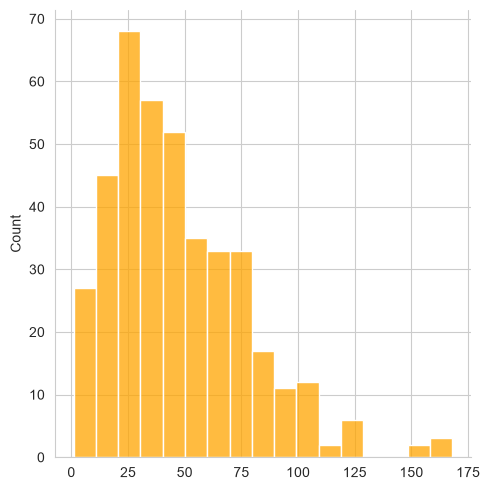

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.displot(degrees, color='orange')

>ER random graphs are characterized by a binomial or poisson like degree distribution. They have a tightly clustered degree distribution around a mean degree and bell curve shape.
>Contrasting, scale free networks or Power-law networks are characterized by a large number of nodes with few links and a long and pronounced tail of few nodes with a very high amount of links.
> In conclusion, id argue that the plotted distribution resembles a ER random graph. It's hard to draw any hard conclusion, but I think we can see a clear bell curve shape clustered around the mean value. Notebly we see the distribution clustering on the left side (so many nodes with compartively fewer links), but i would argue the tail is not as pronounced as one might expect from a scale free network. 

3) What is the degree correlation (assortativity) $\rho_D$? What is its physical meaning?

In [4]:
a = nx.degree_assortativity_coefficient(G)

print(f"Degree corelation: {a}")

Degree corelation: -0.0800119526765869


>The physical meaning of the degree correlation is the likelihood or preference of nodes to attach to nodes that are similiar in some specific meassure. The Degree corelation can range between -1 and 1. So in this case we see a very slight negative corelation, which implies there is no preference for similiar nodes to connect.

4) What is the clustering coefficient $C$?

In [5]:
C = nx.average_clustering(G)

print(f"Clustering coefficient C: {C}")

Clustering coefficient C: 0.2775234288603668


5) What is the average hopcount $E[H]$ of the shortest paths between all node pairs? What is the diameter $H_max$?

In [6]:
avg_hopcount = nx.average_shortest_path_length(G)

H_max = nx.diameter(G)

print(f"Average hopcount C: {avg_hopcount}")
print(f"Diameter: {H_max}")

Average hopcount C: 1.955211535375233
Diameter: 4


6) Has this network the small-world property? Justify your conclusion quantitatively (Hint: Lecture 2).

> According to the lecture, small-world property is a well define term. A graph has a small-world property, if it has a high clustering coefficient and low distances. More concretly it is usualy quantified by the 'small-coefficient' $\sigma = \cfrac{\cfrac{C}{C_r}}{\cfrac{L}{L_r}}$ if $\sigma \gt 1 (C\gg C_r\ and\ L \approx L_r)$ in comparison to a Erdős–Rényi model with same degree on average. The easiest way to quantify this is to generate a Erdős–Rényi random graph with a similar degree and compare our two graphs.

In [7]:
ERG = nx.erdos_renyi_graph(N,E, 1110)
C_ERG = nx.average_clustering(ERG)
L_ERG = nx.average_shortest_path_length(ERG)


sigma = (C / C_ERG) / (avg_hopcount / L_ERG)

print(f"Small-world coefficient sigma: {sigma}")

print(f"Clustering: {C}")
print(f"Path length: {avg_hopcount}")
print(f"Clustering ER: {C_ERG}")
print(f"Path length ER: {L_ERG}")

Small-world coefficient sigma: 0.14194035982255296
Clustering: 0.2775234288603668
Path length: 1.955211535375233
Clustering ER: 1.0
Path length ER: 1.0


> We can see the small world property is not fullfield according to the small-world coefficient, thus this graph does not have small-world property

7) Consider further the weight of each link in $G$, which is the total number of contacts between the corresponding two nodes within $[1, T ]$. Plot the probability density function (distribution) of the link weight (Choose the scales of the two axes and the bins/bin-size for the distribution such that the plot is insightful for interpretation).
The probability density function $f_W(x)$ of the weight $W$ of a link is defined as $f_W(x) = \lim_{\Delta x \to 0} \frac{Pr[x < W \le x + \Delta x]}{\Delta x}$,
the probability that the variable (or the percentage of links whose weight) is within each range or bin $(x, x+\Delta x]$ normalized by the size of the bin $\delta x$. Does $W$ follow a power-law distribution? Explain how you arrived atyour conclusion. Hint: All metrics computed for the network $G$ are recommended to put into a table.

Text(0, 0.5, 'f_W(x)')

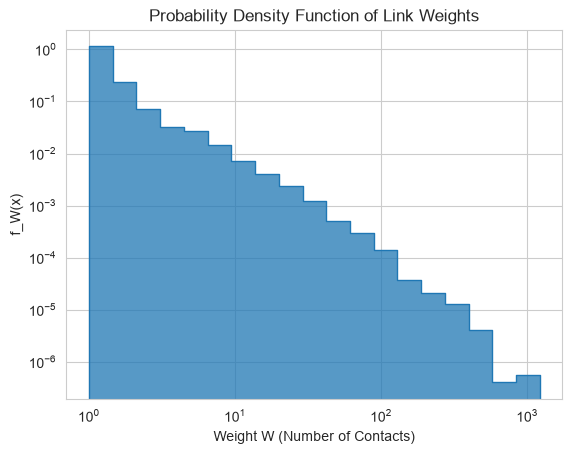

In [ ]:
from IPython.display import display

df["node_min"] = df[["node1", "node2"]].min(axis=1)
df["node_max"] = df[["node1", "node2"]].max(axis=1)

df_weights = df.groupby(["node_min", "node_max"]).size().reset_index(name="weight")

weights = df_weights['weight'].values

bins = np.logspace(np.log10(min(weights)), np.log10(max(weights)), num=20)

sns.histplot(weights, bins=bins, stat="density", element="step")
plt.xscale('log')
plt.yscale('log')





**B.**
We consider the following information spreading process, which is actually a simplified Susceptible-Infected
model but on a temporal network. Initially, at time t = 0, a single node s is infected meaning that this
node possesses the information whereas all the other nodes are Susceptible, thus have not yet perceived the
information. Node s is also called the seed of the information. Whenever an infected node i is in contact with
a susceptible node j at any time step t, the susceptible node becomes infected during the same time step and
could possibly infect other nodes only since the next time step via its contacts with susceptible nodes. Once a
node becomes infected, it stays infected forever. For example, assume that the seed node s has its first contact
at time t = 5 and that contact is with node m. Although node s gets infected since t = 0, it infects a second
node, i.e. node m only at t = 5 when it contacts m. Infection happens only when an infected node and a
susceptible node are in contact. The number of infected nodes is non-decreasing over time.
Simulate the information spreading process on the given temporal network Gdata for N iterations. Each
iteration starts with a different seed node infected at t = 0 and ends at t = T = 3259 the last time step that
the network is measured. Via the N iterations, we consider the spreading process that starts at every node
i ∈ [1, N ]. Record the total number of infected nodes I(t) at each step t for each iteration.

,0,1,2
0,1,1,2
1,1,3,1
2,1,4,5
3,1,6,7
4,1,8,9
...,...,...,...
68674,3259,88,86
68675,3259,88,18
68676,3259,236,86
68677,3259,236,88


8) Taking all the N iterations into count, plot the average number of infected nodes E[I(t)] together with
√︁
its error bar (standard deviation V ar[I(t)]) as a function of the time step t.